# Implementation of FGSM Attack

## Import Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D

## Load the MNIST Dataset

In [2]:
# Load the dataset from keras datasets
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

In [3]:
# Display the shape of training and test data
print(train_images.shape)
print(test_images.shape)
# Each image has 28x28 pixels

(60000, 28, 28)
(10000, 28, 28)


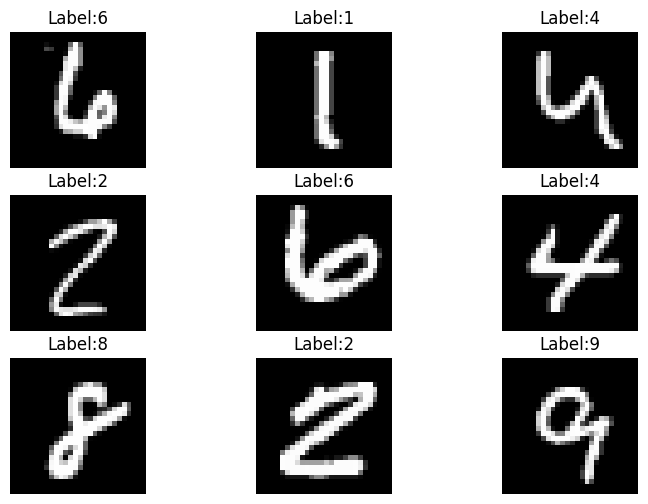

In [4]:
# Display 9 images from the training set adn their labels
plt.figure(figsize=(9, 6))
for n in range(9):
    i = np.random.randint(0, len(train_images), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(train_images[i[0]], cmap='gray')
    plt.title('Label:' + str(train_labels[i[0]]))
    plt.axis('off')

## Data Preprocessing

In [5]:
# Normalize pixel values to range [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

In [6]:
# Reshape the images to have three channels
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [7]:
# Display the shapes of train and test datasets
print('Training data inputs', train_images.shape)
print('Training labels', train_labels.shape)
print('Testing data inputs', test_images.shape)
print('Testing labels', test_labels.shape)

Training data inputs (60000, 28, 28, 1)
Training labels (60000,)
Testing data inputs (10000, 28, 28, 1)
Testing labels (10000,)


# Build and Train the Model

In [8]:
# Define the layers in the model
inputs = Input(shape=(28, 28, 1))
conv1a = Conv2D(filters=32, kernel_size=3, padding='same')(inputs)
conv1b = Conv2D(filters=32, kernel_size=3, padding='same')(conv1a)
pool1 = MaxPooling2D()(conv1b)
flat = Flatten()(pool1)
dense1 = Dense(128, activation='relu')(flat)
outputs = Dense(10, activation='softmax')(dense1)

In [9]:
# Define the model by providing the inputs and outputs
model = Model(inputs, outputs)

In [10]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
# Fit the model to the training dataset
history = model.fit(train_images, train_labels, epochs=5, validation_split=0.2, verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9053 - loss: 0.3123 - val_accuracy: 0.9782 - val_loss: 0.0723
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9843 - loss: 0.0520 - val_accuracy: 0.9803 - val_loss: 0.0689
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9906 - loss: 0.0284 - val_accuracy: 0.9826 - val_loss: 0.0645
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9918 - loss: 0.0232 - val_accuracy: 0.9831 - val_loss: 0.0681
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9938 - loss: 0.0195 - val_accuracy: 0.9809 - val_loss: 0.0953


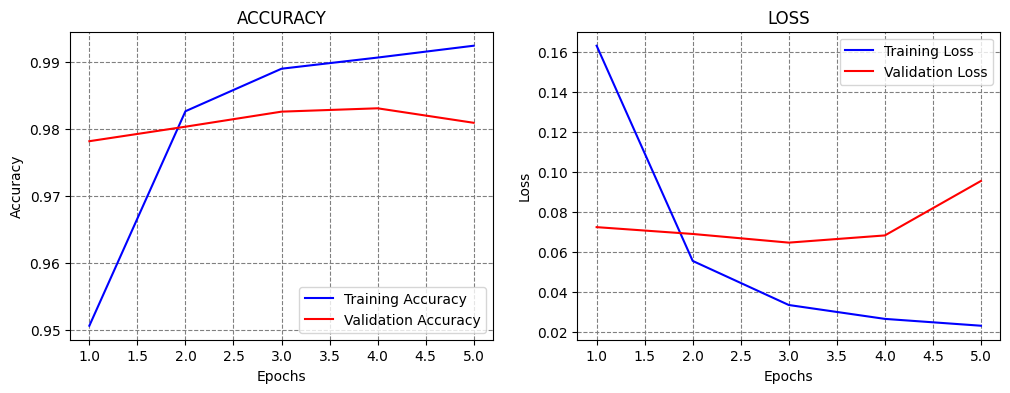

In [12]:
# Plot the accuracy and loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Evaluate the Model

In [13]:
# Calculate and print the accuracy on the test dataset
evals_test = model.evaluate(test_images, test_labels)
print(f"Accuracy on test dataset: {evals_test[1]*100:5.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9739 - loss: 0.1028
Accuracy on test dataset: 97.89%


# FGSM Adversarial Attack

In [14]:
# Take the first test image and create a batch of it
first_image = test_images[0].reshape(1, 28, 28, 1)
print(first_image.shape)

(1, 28, 28, 1)


In [15]:
# Convert the image to tf tensor
first_image_tf = tf.convert_to_tensor(first_image)

In [16]:
# Take the corresponding label
first_label = test_labels[0]
print(first_label)

7


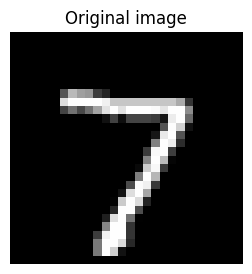

In [17]:
# Plot the image
figure = plt.figure(figsize=(3, 4))
plt.imshow(first_image.squeeze(), cmap="gray")
plt.title('Original image')
plt.axis("off")
plt.show()

FGSM attack: $x_{\text{adv}} = x + \epsilon \cdot \text{sign}(\nabla_{x} \mathcal{L}(C(x, w), y))$

In [18]:
# Use for calculating the gradients of the loss with respect to the inputs

# tensorflow uses the context manager tf.GradientTape() for calculating the gradient
with tf.GradientTape() as tape:
    # watch defines that the gradients will be calculated for the first image
    tape.watch(first_image_tf)

    # Forward pass: calculate the probabilities for the first image
    preds = model(first_image_tf)
    print('Probabilities:', preds)

    # Calculate the loss for the first image
    loss = tf.keras.losses.sparse_categorical_crossentropy(tf.reshape(first_label,(1,)), preds)
    print('\nLoss:', loss)

Probabilities: tf.Tensor(
[[3.0427100e-12 9.5829449e-11 5.5821576e-12 2.3944402e-08 1.3330419e-16
  6.3486593e-15 6.5996301e-20 9.9999988e-01 3.8570391e-10 1.3332502e-07]], shape=(1, 10), dtype=float32)

Loss: tf.Tensor([1.1920928e-07], shape=(1,), dtype=float32)


In [19]:
# Calculate the gradient of the loss w.r.t to the first image
gradient = tape.gradient(loss, first_image_tf)
gradient.shape

TensorShape([1, 28, 28, 1])

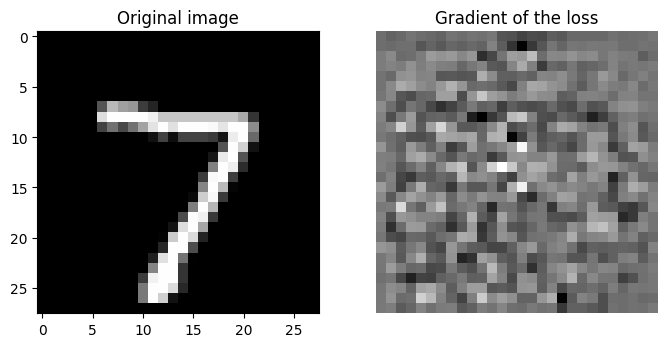

In [20]:
# Plot the image and the gradient
figure = plt.figure(figsize=(8, 6))
plt.subplot(1,2,1)
plt.imshow(first_image.squeeze(), cmap="gray")
plt.title('Original image')
plt.subplot(1,2,2)
plt.imshow(gradient[0], cmap="gray")
plt.title('Gradient of the loss')
plt.axis("off")
plt.show()

In [21]:
# Compute the sign of the gradients
gradient_signs = tf.sign(gradient)

In [22]:
gradient[0,0,:5]

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[-2.6071298e-08],
       [-6.0119859e-08],
       [-3.8053727e-08],
       [-4.4978572e-09],
       [-2.7952165e-08]], dtype=float32)>

In [23]:
gradient_signs[0,0,:5]

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.]], dtype=float32)>

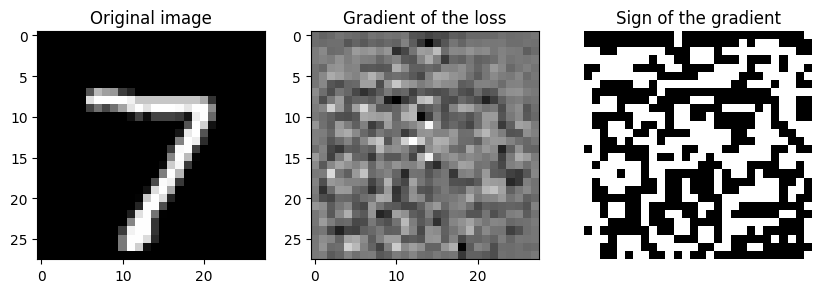

In [24]:
# Plot the image, the gradient, and sign of the gradient
figure = plt.figure(figsize=(10, 6))
plt.subplot(1,3,1)
plt.imshow(first_image[0], cmap="gray")
plt.title('Original image')
plt.subplot(1,3,2)
plt.imshow(gradient[0], cmap="gray")
plt.title('Gradient of the loss')
plt.subplot(1,3,3)
plt.imshow(gradient_signs[0], cmap="gray")
plt.title('Sign of the gradient')
plt.axis("off")
plt.show()

*FGSM* attack: $x_{\text{adv}} = x + \epsilon \cdot \text{sign}(\nabla_{x} \mathcal{L}(C(x, w), y))$

In [25]:
epsilon = 80./255

# Generate the perturbed inputs by adding epsilon times the sign of the gradients
adv_image = tf.add(first_image, epsilon * gradient_signs)

In [26]:
# Find the maximum and minimum pixel values of the adversarial image
print(np.max(adv_image))
print(np.min(adv_image))

1.309804
-0.3137255


In [27]:
# Clip the perturbed inputs to ensure they stay within the valid range (0 to 1)
adv_image = tf.clip_by_value(adv_image, 0, 1)

In [28]:
# Find the maximum and minimum pixel values of the adversarial image
print(np.max(adv_image))
print(np.min(adv_image))

1.0
0.0


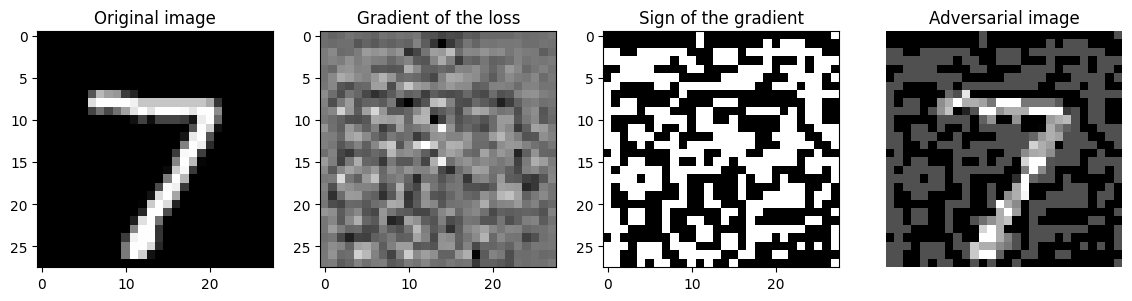

In [29]:
# Plot the image, the gradient, sign of the gradient, and the adversarial image
figure = plt.figure(figsize=(14, 8))
plt.subplot(1,4,1)
plt.imshow(first_image[0], cmap="gray")
plt.title('Original image')
plt.subplot(1,4,2)
plt.imshow(gradient[0], cmap="gray")
plt.title('Gradient of the loss')
plt.subplot(1,4,3)
plt.imshow(gradient_signs[0], cmap="gray")
plt.title('Sign of the gradient')
plt.subplot(1,4,4)
plt.imshow(adv_image[0], cmap="gray")
plt.title('Adversarial image')
plt.axis("off")
plt.show()

In [30]:
# Get the model prediction on the perturbed image
predicted_label = model.predict(adv_image)
predicted_label = np.argmax(predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


In [31]:
print(predicted_label)

9


# Create a function to perform the FGSM attack

In [32]:
def fgsm_attack(model, images, labels, epsilon):

    # Convert the inputs and labels to TensorFlow tensors
    inputs_tf = tf.convert_to_tensor(images)
    labels_tf = tf.convert_to_tensor(labels)

    # Calculate the gradients of the loss with respect to the inputs
    with tf.GradientTape() as tape:
        tape.watch(inputs_tf)
        preds = model(inputs_tf, training=False)
        loss = tf.keras.losses.sparse_categorical_crossentropy(labels_tf, preds)

    gradient = tape.gradient(loss, inputs_tf)

    # Compute the sign of the gradients
    gradient_signs = tf.sign(gradient)

    # Generate the perturbed inputs by adding epsilon times the sign of the gradients
    perturbed_inputs = tf.add(inputs_tf, epsilon * gradient_signs)

    # Clip the perturbed inputs to ensure they stay within the valid range (0 to 1)
    perturbed_inputs = tf.clip_by_value(perturbed_inputs, 0, 1)

    return perturbed_inputs

In [33]:
epsilon = 20./255
perturbed_inputs = fgsm_attack(model, test_images, test_labels, epsilon)

In [34]:
# Get the model prediction on the perturbed image
evals_adv = model.evaluate(perturbed_inputs, test_labels)
print("Classification Accuracy: ", evals_adv[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5149 - loss: 2.8938
Classification Accuracy:  0.5526000261306763
